In [6]:
from pathlib import Path
import re

import numpy as np
import xarray as xr


def _extract_datetime64_from_dataarray(time_da):
    values = np.asarray(time_da.values)
    if np.issubdtype(values.dtype, np.datetime64):
        return values.astype("datetime64[ns]")

    units = str(time_da.attrs.get("units", "")).lower()
    match = re.match(r"^(seconds|minutes|hours|days) since (.+)$", units)
    if not match:
        raise ValueError(
            "Unsupported NetCDF time format. Expected datetime64 values or CF units like 'seconds since ...'."
        )

    unit_key = match.group(1)
    base_time = np.datetime64(match.group(2).strip(), "ns")
    values = np.asarray(values, dtype=float)
    if unit_key == "seconds":
        delta = (values * 1e9).astype("timedelta64[ns]")
    elif unit_key == "minutes":
        delta = (values * 60 * 1e9).astype("timedelta64[ns]")
    elif unit_key == "hours":
        delta = (values * 3600 * 1e9).astype("timedelta64[ns]")
    else:
        delta = (values * 86400 * 1e9).astype("timedelta64[ns]")
    return base_time + delta


def load_waveglider_coordinates_as_dataset(nc_path, lon_bounds=None, lat_bounds=None):
    nc_path = Path(nc_path)
    if not nc_path.exists():
        raise FileNotFoundError(f"Wave glider NetCDF not found: {nc_path}")

    with xr.open_dataset(nc_path) as src:
        time_name = "time" if "time" in src.variables else None
        lon_name = "longitude" if "longitude" in src.variables else ("lon" if "lon" in src.variables else None)
        lat_name = "latitude" if "latitude" in src.variables else ("lat" if "lat" in src.variables else None)

        if time_name is None or lon_name is None or lat_name is None:
            raise KeyError(
                "Could not find required variables in wave glider NetCDF. "
                "Expected time + (longitude or lon) + (latitude or lat)."
            )

        times = _extract_datetime64_from_dataarray(src[time_name])
        lons = np.asarray(src[lon_name].values, dtype=float)
        lats = np.asarray(src[lat_name].values, dtype=float)

    if lons.ndim > 1:
        lons = np.ravel(lons)
    if lats.ndim > 1:
        lats = np.ravel(lats)
    if times.ndim > 1:
        times = np.ravel(times)

    valid = np.isfinite(lons) & np.isfinite(lats)
    if lon_bounds is not None:
        lon_lo, lon_hi = sorted(lon_bounds)
        valid &= (lons >= lon_lo) & (lons <= lon_hi)
    if lat_bounds is not None:
        lat_lo, lat_hi = sorted(lat_bounds)
        valid &= (lats >= lat_lo) & (lats <= lat_hi)

    times = times[valid]
    lons = lons[valid]
    lats = lats[valid]
    if times.size == 0:
        raise ValueError("No valid wave glider points remain after filtering.")

    order = np.argsort(times)
    times = times[order]
    lons = lons[order]
    lats = lats[order]

    wg_ds = xr.Dataset(
        data_vars={
            "longitude": ("time", lons),
            "latitude": ("time", lats),
        },
        coords={"time": times},
        attrs={"source_file": str(nc_path)},
    )
    wg_ds["longitude"].attrs.update({"standard_name": "longitude", "units": "degrees_east"})
    wg_ds["latitude"].attrs.update({"standard_name": "latitude", "units": "degrees_north"})
    return wg_ds


WAVEGLIDER_NC = "/home/mduplessis/share/gliders/waveglider/wg1169/wg1169_WHIRLS_Mission3_L1.nc"
wg_ds = load_waveglider_coordinates_as_dataset(
    WAVEGLIDER_NC,
    lon_bounds=(10, 20),
    lat_bounds=(-38, -32),
)

wg_ds

<xarray.Dataset> Size: 8kB
Dimensions:    (time: 329)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2026-06-05T05:10:00 ... 2026-06-09T1...
Data variables:
    longitude  (time) float64 3kB 18.43 18.42 18.42 18.42 ... 16.28 16.28 16.27
    latitude   (time) float64 3kB -33.9 -33.9 -33.9 ... -34.81 -34.81 -34.81
Attributes:
    source_file:  /home/mduplessis/share/gliders/waveglider/wg1169/wg1169_WHI...

In [12]:
wg = xr.open_dataset(WAVEGLIDER_NC)

wg

<xarray.Dataset> Size: 429kB
Dimensions:                         (time: 329, depth: 25)
Coordinates:
  * time                            (time) datetime64[ns] 3kB 2026-06-05T05:1...
  * depth                           (depth) float64 200B 4.0 6.0 ... 51.0 53.0
    latitude                        (time) float64 3kB ...
    longitude                       (time) float64 3kB ...
Data variables: (12/112)
    TEMP_AIR_AIRMAR_MEAN            (time) float64 3kB ...
    BARO_PRES_AIRMAR_MEAN           (time) float64 3kB ...
    WIND_FROM_AIRMAR_MEAN           (time) float64 3kB ...
    WIND_FROM_AIRMAR_STDDEV         (time) float64 3kB ...
    GUST_WND_DIR_AIRMAR_MEAN        (time) float64 3kB ...
    WIND_SPEED_AIRMAR_MEAN          (time) float64 3kB ...
    ...                              ...
    WAVE_SIGNIFICANT_HEIGHT         (time) float64 3kB ...
    WAVE_AVERAGE_PERIOD             (time) float64 3kB ...
    WAVE_DOMINANT_PERIOD            (time) float64 3kB ...
    WAVE_DOMINANT_DIRECTION         (time) float64 3kB ...
    WATER_CURRENT_EAST_MEAN         (depth, time) float64 66kB ...
    WATER_CURRENT_NORTH_MEAN        (depth, time) float64 66kB ...
Attributes: (12/33)
    naming_authority:          polargliders.com
    Conventions:               CF-1.10, ACDD-1.3
    standard_name_vocabulary:  CF Standard Name Table v79
    keywords:                  trajectory, uncrewed surface vehicle, Waveglid...
    featureType:               Trajectory
    cdm_data_type:             Trajectory
    ...                        ...
    time_coverage_start:       2026-06-05T05:10:00.000000000
    time_coverage_end:         2026-06-09T13:30:00.000000000
    geospatial_lat_min:        -34.8134933333333
    geospatial_lat_max:        -33.865285
    geospatial_lon_min:        16.274
    geospatial_lon_max:        18.42607

Text(0.5, 1.0, 'Wave Glider Track Colored by Time')

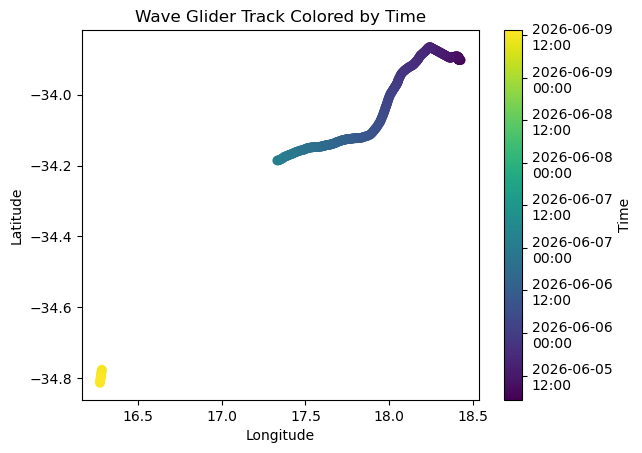

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

time_py = wg_ds["time"].values.astype("datetime64[ms]").astype("O")
time_num = mdates.date2num(time_py)

sc = plt.scatter(wg_ds["longitude"], wg_ds["latitude"], c=time_num, cmap="viridis")
cbar = plt.colorbar(sc, label="Time")
cbar.formatter = mdates.DateFormatter("%Y-%m-%d\n%H:%M")
cbar.update_ticks()

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Wave Glider Track Colored by Time")